# Limpieza de datos previa

Se extraen datos a traves de diferentes herramientas no code como outscraper, livescraper o hasData. Se utilizan las columnas de nombre del lugar, comentario del usuario, calificacion, fecha y total de reseñas existentes del lugar.

In [1]:
import os
os.chdir("..")
from src.utils.detectar_espanol_fasttext import detectar_espanol_fasttext
from src.utils.detectar_idioma_lang import detectar_idioma_lang
from src.utils.detectar_idoma_lingua import detectar_idoma_lingua
from src.utils.quitar_emojis import quitar_emojis
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

## Arenal y Manuel

In [2]:
arenal = pd.read_csv("data/raw/reseñas_arenal.csv")
manuel = pd.read_csv("data/raw/manuel.csv")

cols_outscraper = ['name','reviews', 'review_rating', 'review_text' , 'review_datetime_utc']

manuel = manuel[cols_outscraper]
arenal = arenal[cols_outscraper]

new_cols = {
    'name': 'business_name',
    'reviews': 'total_reviews',
    'review_rating': 'review_rating',
    'review_text': 'review_text',
    'review_datetime_utc': 'datetime_utc',
}

manuel = manuel.rename(columns=new_cols)
arenal = arenal.rename(columns=new_cols)

manuel.head(3)

,business_name,total_reviews,review_rating,review_text,datetime_utc
0,Parque Nacional Manuel Antonio,24467,3,Touristy and very overrated. Many other great ...,06/05/2026 05:46:47
1,Parque Nacional Manuel Antonio,24467,5,"Increíble!! Lleno de flora y fauna del país, c...",06/05/2026 03:38:27
2,Parque Nacional Manuel Antonio,24467,5,NaN,06/04/2026 21:58:36


## Ruinas

In [3]:
ruinas = pd.read_csv("data/raw/ruinas.csv", sep=";")

cols_hasData = ["rating", "isoDate", "snippet"]
ruinas = ruinas[cols_hasData]

ruinas['business_name'] = 'Ruinas de la Parroquia de Santiago Apóstol'
ruinas ['total_reviews']= 4035

ruinas["isoDate"] = pd.to_datetime(ruinas["isoDate"])
ruinas["isoDate"] = ruinas["isoDate"].dt.strftime("%d/%m/%Y %H:%M:%S")


nuevas_hasData = {
    'reviews': 'total_reviews',
    'review_rating': 'review_rating',
    'snippet': 'review_text',
    'isoDate': 'datetime_utc',
    'rating': 'review_rating'
}

ruinas = ruinas.rename(columns=nuevas_hasData)
ruinas.head(3)

,review_rating,datetime_utc,review_text,business_name,total_reviews
0,5,01/06/2026 02:41:01,"Me encantó el lugar, limpio y hermoso muy bien...",Ruinas de la Parroquia de Santiago Apóstol,4035
1,5,25/05/2026 03:15:15,Muy bonito lugar 💯,Ruinas de la Parroquia de Santiago Apóstol,4035
2,5,02/06/2026 11:57:48,NaN,Ruinas de la Parroquia de Santiago Apóstol,4035


## Kalambu y Museo de los niños

In [4]:
kalambu = pd.read_csv("data/raw/kalambu.csv")
museo = pd.read_csv("data/raw/niños.csv")
cols_livescraper = ['business_name', 'total_reviews', 'review_rating', 'review_text', 'review_datetime_utc']
kalambu = kalambu[cols_livescraper]
museo = museo[cols_livescraper]
kalambu = kalambu.rename(columns={'review_datetime_utc': 'datetime_utc'})
museo = museo.rename(columns={'review_datetime_utc': 'datetime_utc'})
museo.head(2)

,business_name,total_reviews,review_rating,review_text,datetime_utc
0,Museo de los Niños Costa Rica,8284,5,Mis amigxs ticxs no me recomendaban ir pero la...,2026-01-11 16:00:17
1,Museo de los Niños Costa Rica,8284,5,Muy bonita la experiencia un lugar único y mág...,2026-01-27 22:52:02


## Concatenación

In [5]:
resenias = pd.concat([arenal, manuel, kalambu, ruinas, museo], ignore_index=True, join='inner')
print(len(resenias))
resenias.head(2)

2320


,business_name,total_reviews,review_rating,review_text,datetime_utc
0,Volcán Arenal,1626,5,No sé cómo explicar la belleza incomparable de...,02/10/2026 14:39:19
1,Volcán Arenal,1626,5,Volcán activo en parque nacional homónimo en A...,09/29/2025 19:00:19


In [6]:
resenias = resenias.dropna(subset=['review_text'])
print(len(resenias))

1880


## Deteccion de idiomas

Se seleccionan automaticamente solo las reseñas que esten en español

### Langdetect

Utiliza el algoritmo Naive Bayes para detectar el idioma, muy similar al detector de lenguajes que usa Google Translate

In [7]:
resenias['review_text'] = resenias['review_text'].apply(quitar_emojis)
resenias['review_text'] = resenias['review_text'].apply(lambda x: ' '.join(x.split())) # divide el texto por palabras y lo vuelve a unir de manera que solo haya un espacio. Quita saltos de linea y espacios multiples

resenias['idioma_langd'] = resenias['review_text'].apply(detectar_idioma_lang)
with pd.option_context('display.max_colwidth', 150):
    display(resenias[['review_text','idioma_langd']].sample(10, random_state=555))

,review_text,idioma_langd
1341,Muy bonito lugar,tl
367,Excelente,ro
1971,"Siempre es chiva visitar el museo, se pasa súper genial con lxs chiquitines de la casa, hay salas nuevas y unas renovadas, desde la sala de estimu...",es
1871,"El museo está muy bien cuidado, las atracciones muy interesantes, pero para el ingreso hay que tener paciencia, se puede durar de 20 a 35 minutos ...",es
1175,"El mejor parque acuático de la Fortuna, la atención es muy buena y los precios muy cómodos.",es
126,Las maravillas del mundo no cuesta nada admirarlas...,es
2259,Una experiencia única para chicos y grandes !!,es
1920,"Las visitas guiadas son super explicativas, nos tocó con Valeria es super linda, amable, paciente y creativa. Extremadamente cuidadosos con la lim...",es
1102,Lugar muy bello. Mucha naturaleza y excelentes precios de los alimentos,es
1216,"Las instalaciones están sumamente descuidadas, los toboganes están sumamente sucios los flotadores hasta negros están se nota que ni cloro suli le...",es


En su mayoria clasifica correctamente las reseñas al español, sin embargo, se ve que falla en textos cortos.

### Fasttext

Se trata de un modelo preentrenado por Facebook específicamente para la detección de idiomas

In [8]:
resenias['es_espanol'] = resenias['review_text'].apply(detectar_espanol_fasttext)

with pd.option_context('display.max_colwidth', 150):
    display(resenias[['review_text', 'es_espanol']].sample(10, random_state=555))

,review_text,es_espanol
1341,Muy bonito lugar,False
367,Excelente,False
1971,"Siempre es chiva visitar el museo, se pasa súper genial con lxs chiquitines de la casa, hay salas nuevas y unas renovadas, desde la sala de estimu...",True
1871,"El museo está muy bien cuidado, las atracciones muy interesantes, pero para el ingreso hay que tener paciencia, se puede durar de 20 a 35 minutos ...",True
1175,"El mejor parque acuático de la Fortuna, la atención es muy buena y los precios muy cómodos.",True
126,Las maravillas del mundo no cuesta nada admirarlas...,False
2259,Una experiencia única para chicos y grandes !!,True
1920,"Las visitas guiadas son super explicativas, nos tocó con Valeria es super linda, amable, paciente y creativa. Extremadamente cuidadosos con la lim...",True
1102,Lugar muy bello. Mucha naturaleza y excelentes precios de los alimentos,True
1216,"Las instalaciones están sumamente descuidadas, los toboganes están sumamente sucios los flotadores hasta negros están se nota que ni cloro suli le...",True


Este modelo es mucho mas lento y en nuestro caso se ha equivocado tanto en textos cortos como en textos largos.

### Comparación

In [9]:
fasttext_esp = resenias[resenias['es_espanol'] == True]
langdetect_esp = resenias[resenias['idioma_langd'] == 'es']

print(len(fasttext_esp))
print(len(langdetect_esp))

1286
1453


A continuacion se muestran aquellas reseñas en las que los modelos difieren acerca del idioma encontrado

In [10]:
idx_solo_df1 = fasttext_esp.index.difference(langdetect_esp.index)
idx_solo_df2 = langdetect_esp.index.difference(fasttext_esp.index)

exclusivos_df1 = fasttext_esp.loc[idx_solo_df1]
exclusivos_df2 = langdetect_esp.loc[idx_solo_df2]

todos_los_exclusivos = pd.concat([exclusivos_df1, exclusivos_df2])

with pd.option_context('display.max_colwidth', 150):
    display(todos_los_exclusivos[['review_text','idioma_langd','es_espanol']].sample(10, random_state=888))

,review_text,idioma_langd,es_espanol
1040,"Muy lindo el lugar, limpio, mucha naturaleza",es,False
1278,Muy bonito el lugar,tl,True
171,"Un paisaje maravilloso, perfecto para visitar a pie, merece la pena verlo.",es,False
689,Espectacular lugar. Una experiencia maravillosa. Recomendado!,es,False
1173,Un lugar familiar para pasar un día y compartir..! Excelente lugar y precio accesible..!,es,False
275,Una experiencia inolvidable gracias familia,es,False
222,Imponente volcan y hermoso el entorno que lo rodea,es,False
135,Hermoso sitio. El volcán se ve imponente. La lava se nota bajar de la montaña en las noches.,es,False
65,Impresionante aunque el volcán no esté activo,es,False
391,Sobrecogedor,es,False


Los resultados muestran una clara superioridad en la clasificacion de idiomas de parte de la libreria langdetect en nuestras reseñas

In [11]:
resenias_langd = resenias[resenias['idioma_langd'] == 'es']
extanjeras = resenias[resenias['idioma_langd'] != 'es']

extanjeras[['review_text','idioma_langd']].head(5)

,review_text,idioma_langd
109,Excelente bonito. Full calor,it
140,Hermoso e imponente,it
154,Me gusta la ap,ca
163,Impresionante la vista del coloso,it
176,Hermoso,en


### Lingua

Es utilizada para detectar idiomas en textos cortos

In [12]:
extanjeras['idioma_lingua'] = extanjeras['review_text'].apply(detectar_idoma_lingua)

with pd.option_context('display.max_colwidth', 150):
    display(extanjeras[['review_text', 'idioma_lingua']].sample(10, random_state=888))

,review_text,idioma_lingua
206,Bello hay q revisar clima,es
668,Great place to visit. Lots of monkeys and sloths. Beach is great,en
1524,Free to walk in and just enjoy the nature and learn some of the history of the location. Right next to the city square,en
446,"Lovely volcano ! The hike is super easy, but tge view is nice:) Unfortunately, because of high humidity you can rarely see all of the volcano:( De...",en
700,Belle reserve naturelle. Ne vous laissez pas scamer par les guides en amont du parc qui vous disent que vous allez rien voir et que vous ne pouvez...,fr
714,"Disney-esque. Huge crowds, pushy guides, few animals or birds. Stupidly overpriced. Avoid.",en
707,Très bien,fr
599,Beaux mais beaucoup trop de monde et les personnes ne respectent pas les animaux !,fr
718,Wildlife everywhere! Highly recommend you use a guide since the wildlife is hard to spot on your own. Beaches are beautiful swimmable beaches.,en
406,"RL Volcano isn’t just a hike — it’s a pilgrimage. You climb up for the views, stay for the bragging rights, and come down feeling like you’ve been...",en


## Corpus en español

In [13]:
resenias_esp = pd.concat([extanjeras[extanjeras['idioma_lingua'] == 'es'], resenias_langd], ignore_index=True)
resenias_esp = resenias_esp.drop(columns=['idioma_lingua', 'es_espanol','idioma_langd'])
resenias_esp['datetime_utc'] = resenias_esp['datetime_utc'].str.replace('-', '/')
print(len(resenias_esp))
resenias_esp.sample(3)

1531


,business_name,total_reviews,review_rating,review_text,datetime_utc
1230,Museo de los Niños Costa Rica,8284,5,"Excelente, muy bonita experiencia, me encantó ...",2019/05/19 23:29:55
1427,Museo de los Niños Costa Rica,8284,3,"Es un lugar para recordar, volver a nuestra ed...",2022/09/21 01:49:07
905,Kalambu Hot Springs,4350,3,"El lugar es bonito, solo q si el área del rest...",2022/07/01 23:15:48


In [14]:
resenias_esp.to_csv('data/processed/resenas_clean.csv',  sep=';',index=False)

# Exploracion de datos

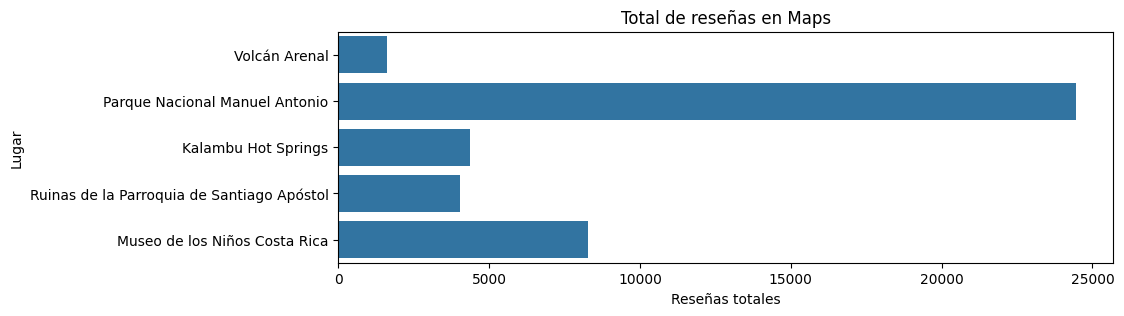

In [15]:
total_resenias_lugares  = resenias_esp[['business_name', 'total_reviews']]
total_resenias_lugares = total_resenias_lugares.drop_duplicates()

plt.figure(figsize=(10, 3))
sns.barplot(y='business_name', x='total_reviews', data=total_resenias_lugares)

plt.xlabel('Reseñas totales')
plt.ylabel('Lugar')
plt.title('Total de reseñas en Maps');

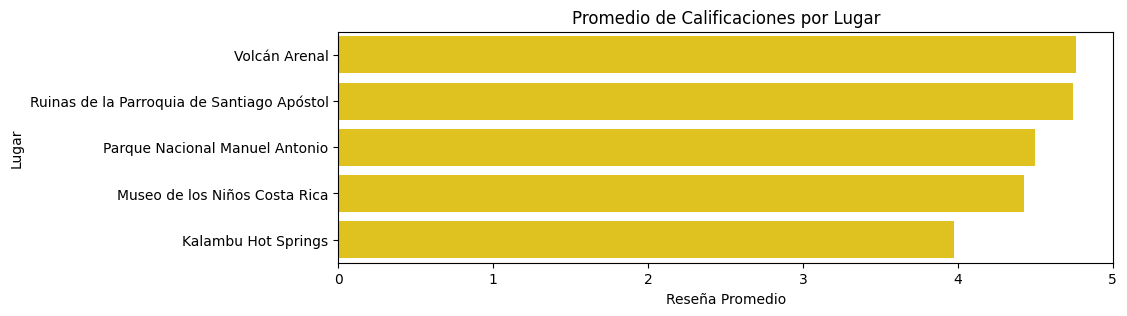

In [16]:
df_rating = (
    resenias_esp.groupby(["business_name"])["review_rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 3))
sns.barplot(x="review_rating", y="business_name", data=df_rating, color="gold")

plt.title("Promedio de Calificaciones por Lugar")
plt.xlabel("Reseña Promedio")
plt.ylabel("Lugar");

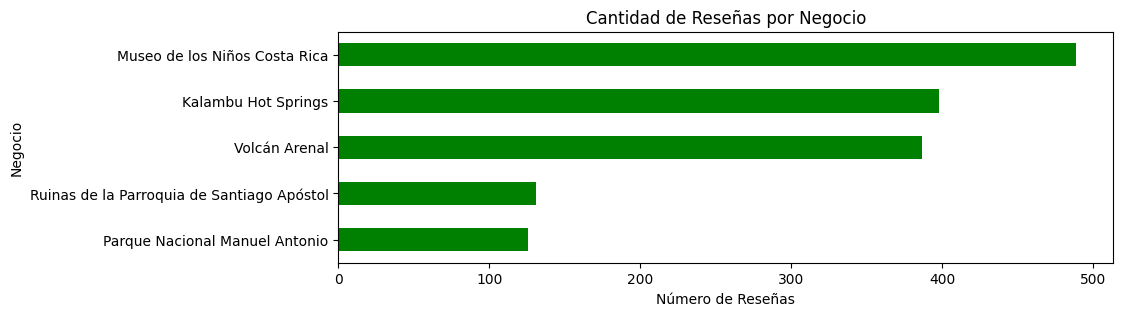

In [17]:
conteo_resenias = (
    resenias_esp.groupby(["business_name"])
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 3))
conteo_resenias.plot(kind="barh", color="green")

plt.gca().invert_yaxis()
plt.title("Cantidad de Reseñas por Negocio")
plt.xlabel("Número de Reseñas")
plt.ylabel("Negocio");

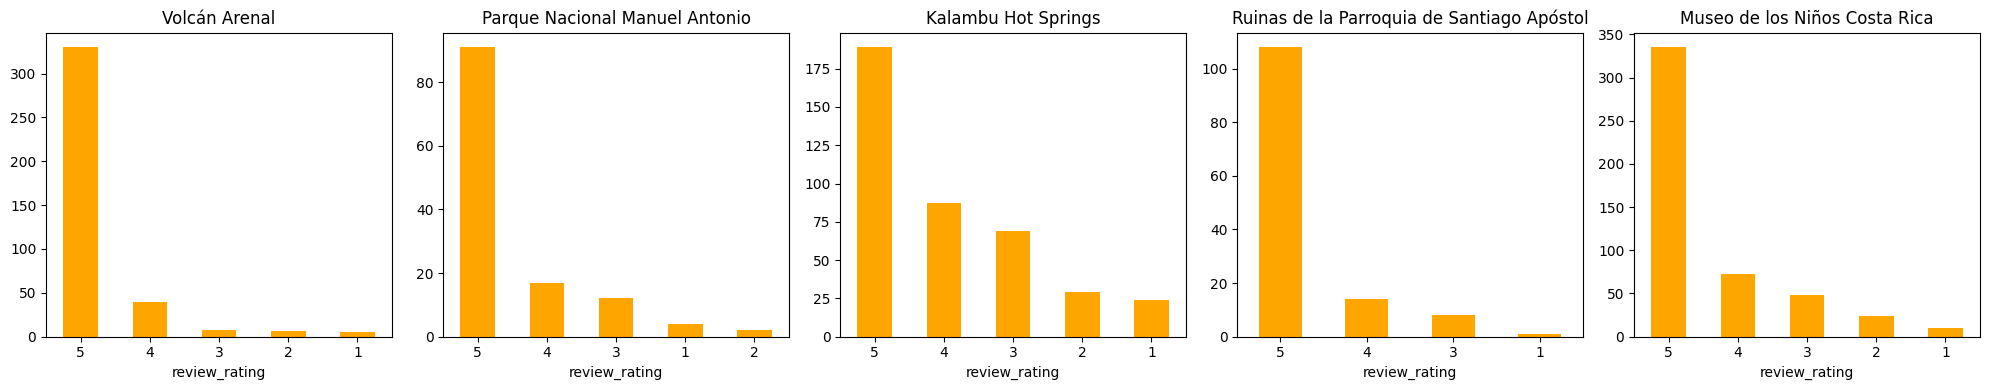

In [18]:
negocios = resenias_esp['business_name'].unique()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, negocio in enumerate(negocios):
    ax = axes[i]
    resenias_esp[resenias_esp['business_name'] == negocio]['review_rating'].value_counts().plot(kind='bar', ax=ax, rot=0, color='orange')
    ax.set_title(negocio)

plt.tight_layout()
plt.show()